In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# create dataset
data = pd.DataFrame({
    "Feature1": [2.5, 0.5, 2.2, 1.9, 3.1, 2.3, 2.0, 1.0, 1.5, 1.1],
    "Feature2": [2.4, 0.7, 2.9, 2.2, 3.0, 2.7, 1.6, 1.1, 1.6, 0.9]
})

print("Original Data:\n", data)

# check missing values
print("\nMissing Values:\n", data.isnull().sum())

# fill missing values
data.fillna(data.mean(numeric_only=True), inplace=True)

# standardize data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

print("\nStandardized Data:\n", scaled_data)

# apply PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

# create dataframe of principal components
pca_df = pd.DataFrame(pca_data, columns=["PC1", "PC2"])

print("\nPCA Result:\n", pca_df)

# explained variance
print("\nExplained Variance Ratio:\n", pca.explained_variance_ratio_)

# save result
pca_df.to_csv("pca_output.csv", index=False)

print("\nPCA Completed")

Original Data:
    Feature1  Feature2
0       2.5       2.4
1       0.5       0.7
2       2.2       2.9
3       1.9       2.2
4       3.1       3.0
5       2.3       2.7
6       2.0       1.6
7       1.0       1.1
8       1.5       1.6
9       1.1       0.9

Missing Values:
 Feature1    0
Feature2    0
dtype: int64

Standardized Data:
 [[ 0.92627881  0.61016865]
 [-1.7585873  -1.506743  ]
 [ 0.52354889  1.23278973]
 [ 0.12081898  0.36112022]
 [ 1.73173864  1.35731394]
 [ 0.6577922   0.9837413 ]
 [ 0.25506228 -0.38602507]
 [-1.08737078 -1.00864614]
 [-0.41615425 -0.38602507]
 [-0.95312747 -1.25769457]]

PCA Result:
         PC1       PC2
0  1.086432 -0.223524
1 -2.308937  0.178081
2  1.241919  0.501509
3  0.340782  0.169919
4  2.184290 -0.264758
5  1.160739  0.230481
6 -0.092605 -0.453317
7 -1.482108  0.055667
8 -0.567226  0.021305
9 -1.563287 -0.215361

Explained Variance Ratio:
 [0.96296464 0.03703536]

PCA Completed


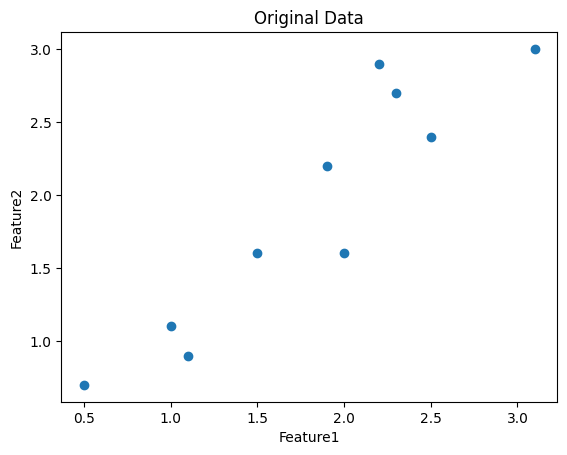

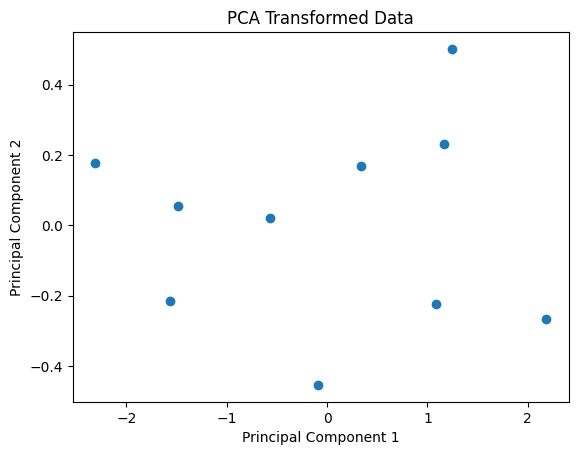

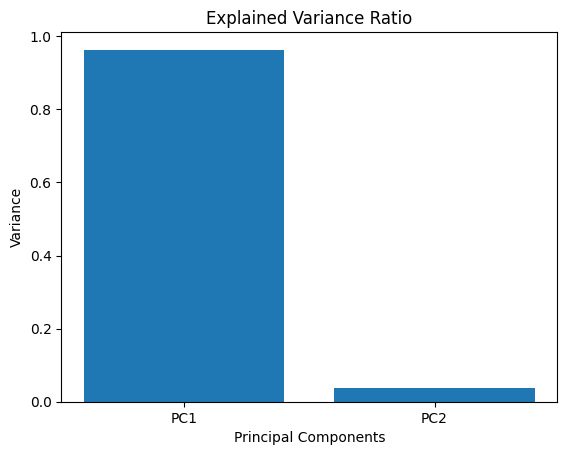

In [2]:
import matplotlib.pyplot as plt

# scatter plot of original data
plt.figure()
plt.scatter(data["Feature1"], data["Feature2"])
plt.title("Original Data")
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.show()

# scatter plot of PCA components
plt.figure()
plt.scatter(pca_df["PC1"], pca_df["PC2"])
plt.title("PCA Transformed Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

# explained variance plot
plt.figure()
plt.bar(["PC1", "PC2"], pca.explained_variance_ratio_)
plt.title("Explained Variance Ratio")
plt.xlabel("Principal Components")
plt.ylabel("Variance")
plt.show()